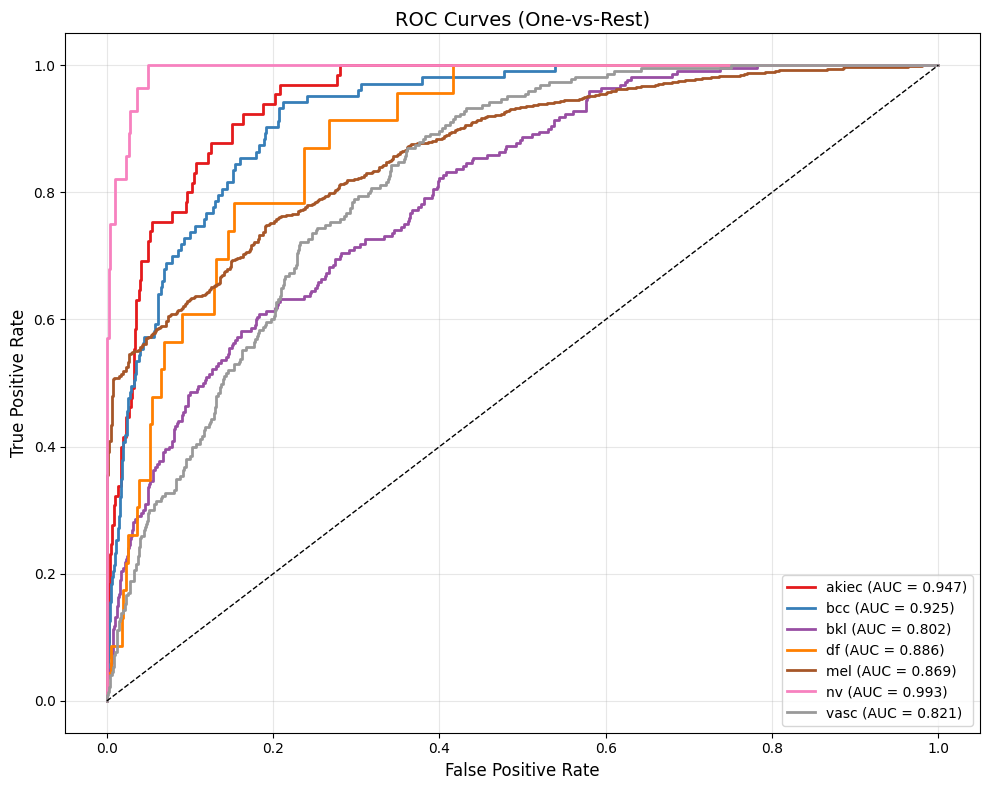

In [ ]:
from sklearn.preprocessing import label_binarize

def plot_roc_curves(y_true, y_pred_proba, class_names, num_classes=7):
    y_true_bin = label_binarize(y_true, classes=range(num_classes))

    plt.figure(figsize=(10, 8))
    colors = plt.cm.Set1(np.linspace(0, 1, num_classes))

    for i, (class_name, color) in enumerate(zip(class_names.values(), colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        auc_score = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
        plt.plot(fpr, tpr, color=color, linewidth=2,
                label=f'{class_name} (AUC = {auc_score:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves (One-vs-Rest)', fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curves.png', dpi=150)
    plt.show()

plot_roc_curves(y_test, y_pred_proba, class_names)


Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training KNN...

Model Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.701448   0.655606 0.701448  0.666473
      Random Forest  0.725911   0.672355 0.725911  0.677970
                KNN  0.708437   0.646212 0.708437  0.656270
         CNN (Ours)  0.523215   0.762576 0.523215  0.576957


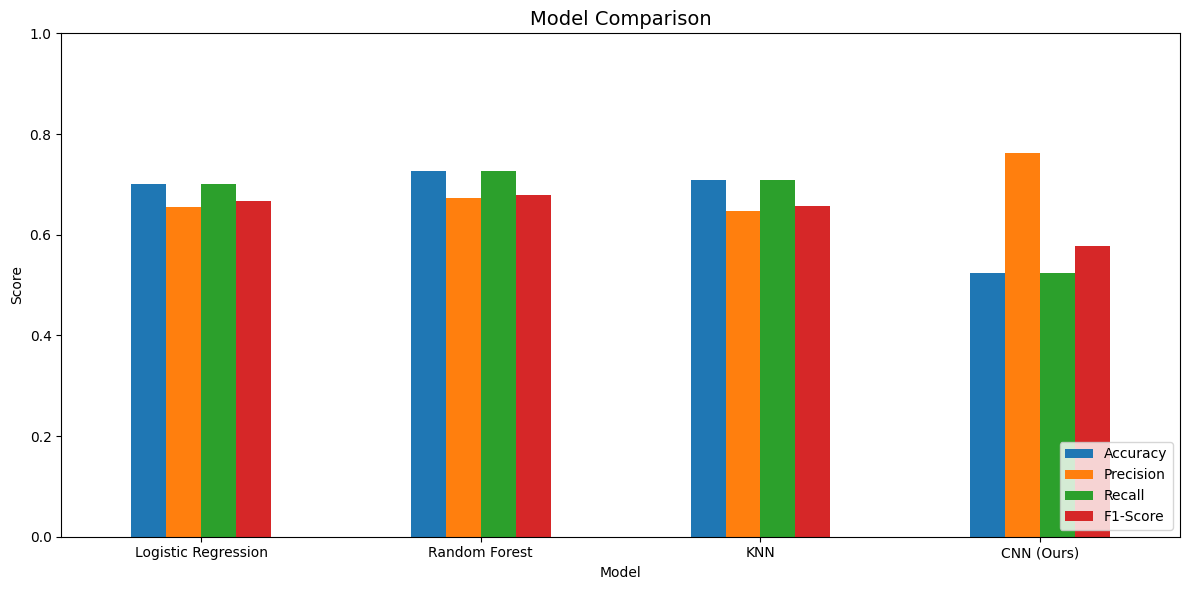

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# Flatten images for traditional ML
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Train baseline models
baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
}

results = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

for name, clf in baselines.items():
    print(f"Training {name}...")
    clf.fit(X_train_flat, y_train)
    y_pred_baseline = clf.predict(X_test_flat)

    acc = accuracy_score(y_test, y_pred_baseline)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_baseline, average='weighted')

    results['Model'].append(name)
    results['Accuracy'].append(acc)
    results['Precision'].append(prec)
    results['Recall'].append(rec)
    results['F1-Score'].append(f1)

# Add CNN results
results['Model'].append('CNN (Ours)')
results['Accuracy'].append(test_accuracy)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
results['Precision'].append(prec)
results['Recall'].append(rec)
results['F1-Score'].append(f1)

# Display comparison
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))

# Plot comparison
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(12, 6), rot=0
)
plt.title('Model Comparison', fontsize=14)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


Last conv layer: conv2d_4


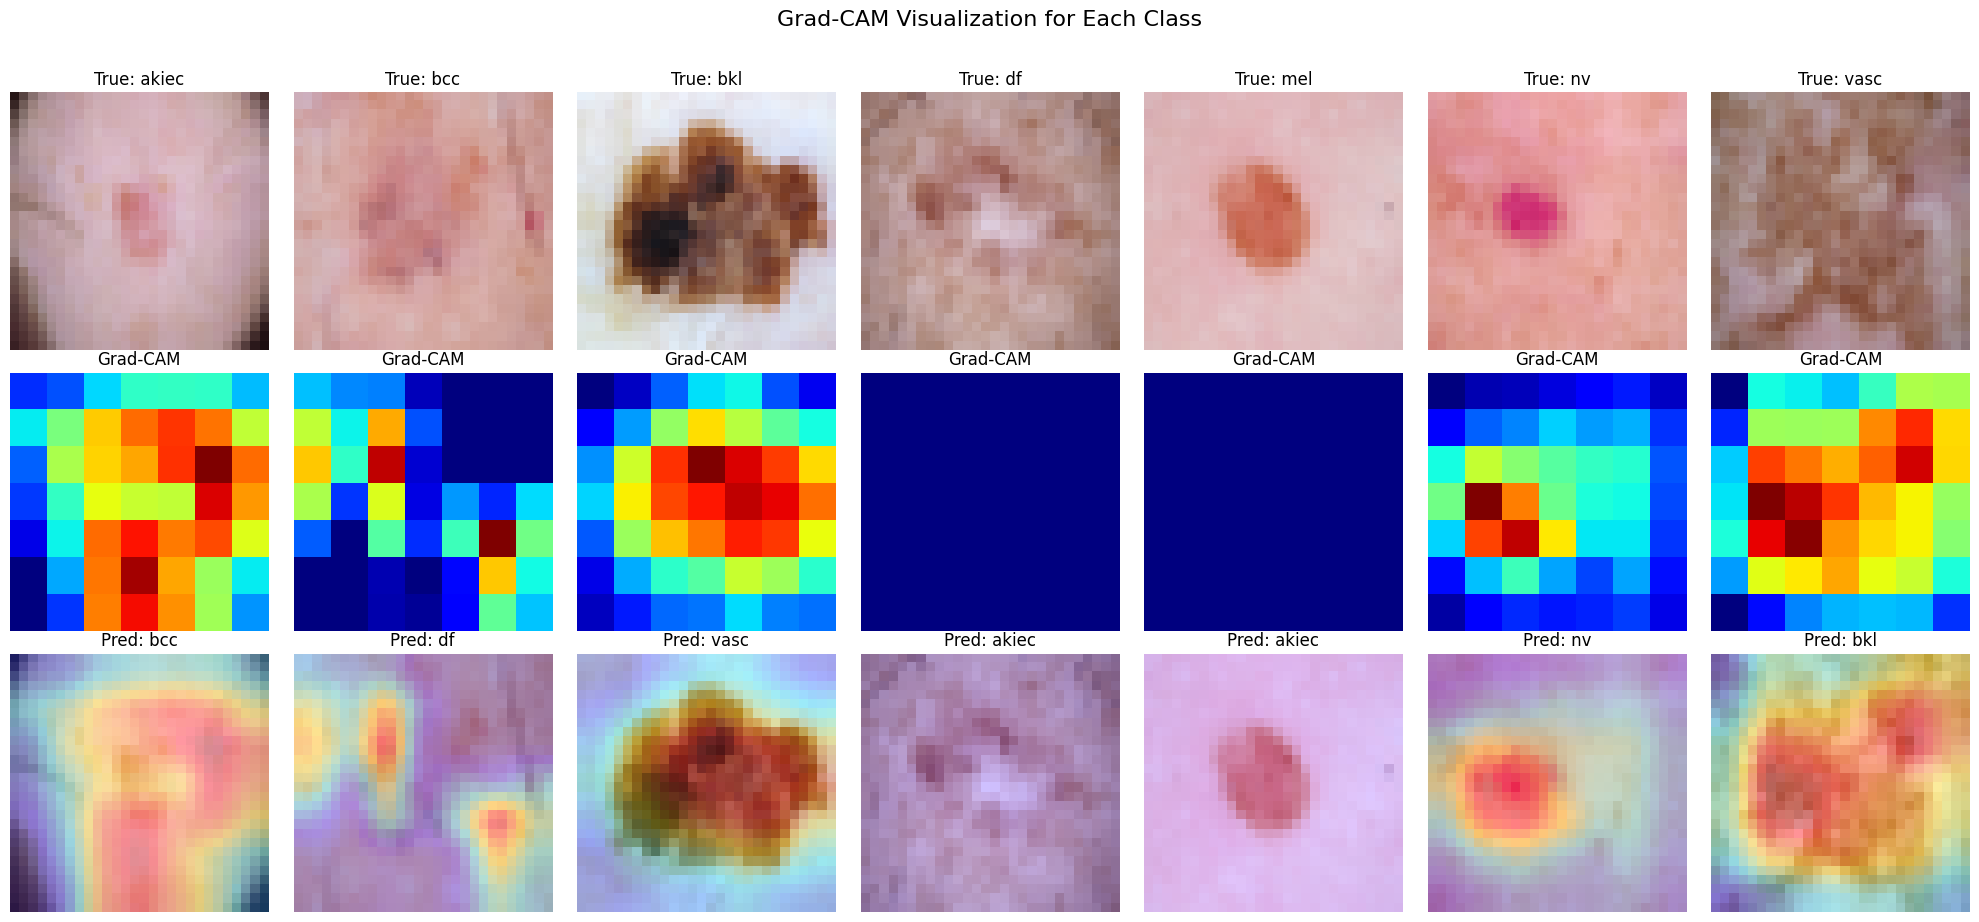

In [ ]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap"""

    # 1. Create a model that outputs the activation maps from the last conv layer
    feature_extractor = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(last_conv_layer_name).output
    )

    # 2. Create a model that maps the activation maps to the final class predictions
    # This requires recreating the layers after the last conv layer
    classifier_input = tf.keras.Input(shape=feature_extractor.output.shape[1:])
    x = classifier_input

    # Get all layers after the last conv layer
    classifier_layers = []
    found_conv_layer = False
    for layer in model.layers:
        if layer.name == last_conv_layer_name:
            found_conv_layer = True
            continue # Skip the last conv layer itself

        if found_conv_layer:
            classifier_layers.append(layer)

    # Build the classifier model by applying these layers sequentially
    for layer in classifier_layers:
        x = layer(x)

    classifier = tf.keras.models.Model(inputs=classifier_input, outputs=x)

    # Convert img_array to a TensorFlow tensor
    img_tensor = tf.cast(tf.convert_to_tensor(img_array), tf.float32)

    with tf.GradientTape() as tape:
        # Watch the input to the classifier (output of feature extractor)
        conv_outputs = feature_extractor([img_tensor])
        tape.watch(conv_outputs)

        # Pass the processed features through the classifier
        predictions = classifier(conv_outputs)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    if grads is None:
        print(f"Warning: Gradients are None for class_channel: {class_channel} with respect to conv_outputs. Returning a zero heatmap.")
        if conv_outputs.shape.rank == 4:
            return np.zeros(conv_outputs.shape[1:3].as_list(), dtype=np.float32)
        else:
            return np.zeros((28, 28), dtype=np.float32)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_heatmap = tf.math.reduce_max(heatmap)
    if max_heatmap == 0:
        return heatmap.numpy()
    heatmap = heatmap / max_heatmap

    return heatmap.numpy()

def display_gradcam(image, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on image"""
    heatmap = np.uint8(255 * heatmap)

    heatmap_resized = cv2.resize(heatmap, (28, 28))
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

    superimposed = heatmap_colored * alpha + image
    superimposed = superimposed / superimposed.max()

    return superimposed

# Find the last convolutional layer
last_conv_layer = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer.name
        break

print(f"Last conv layer: {last_conv_layer}")

# Generate Grad-CAM for sample images
fig, axes = plt.subplots(3, 7, figsize=(20, 9))

for class_id in range(7):
    # Get a sample from this class
    idx = np.where(y_test == class_id)[0][0]
    img = X_test[idx]
    img_array = np.expand_dims(img, 0)

    # Get prediction
    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred)

    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)
    superimposed = display_gradcam(img, heatmap)

    # Plot
    axes[0, class_id].imshow(img)
    axes[0, class_id].set_title(f'True: {class_names[class_id]}')
    axes[0, class_id].axis('off')

    axes[1, class_id].imshow(heatmap, cmap='jet')
    axes[1, class_id].set_title('Grad-CAM')
    axes[1, class_id].axis('off')

    axes[2, class_id].imshow(superimposed)
    axes[2, class_id].set_title(f'Pred: {class_names[pred_class]}')
    axes[2, class_id].axis('off')

plt.suptitle('Grad-CAM Visualization for Each Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

Number of misclassifications: 955


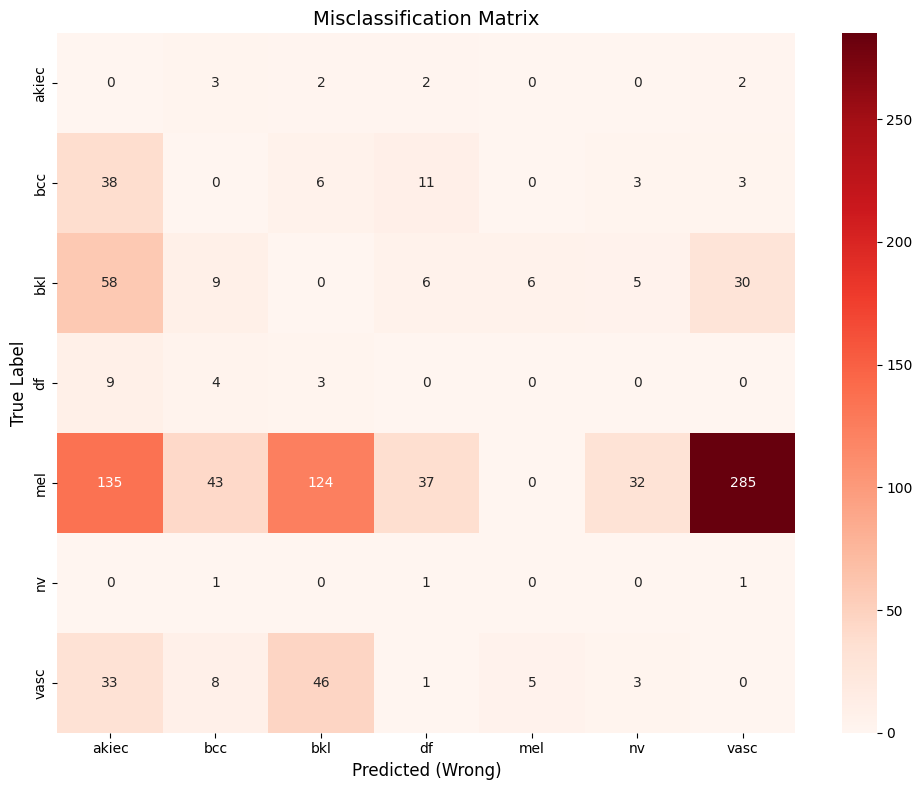

In [ ]:
# Analyze misclassifications
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Number of misclassifications: {len(misclassified_idx)}")

# Show misclassification patterns
misclass_matrix = np.zeros((7, 7), dtype=int)
for idx in misclassified_idx:
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    misclass_matrix[true_label, pred_label] += 1

plt.figure(figsize=(10, 8))
sns.heatmap(misclass_matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=list(class_names.values()),
            yticklabels=list(class_names.values()))
plt.title('Misclassification Matrix', fontsize=14)
plt.xlabel('Predicted (Wrong)', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('misclassification_matrix.png', dpi=150)
plt.show()


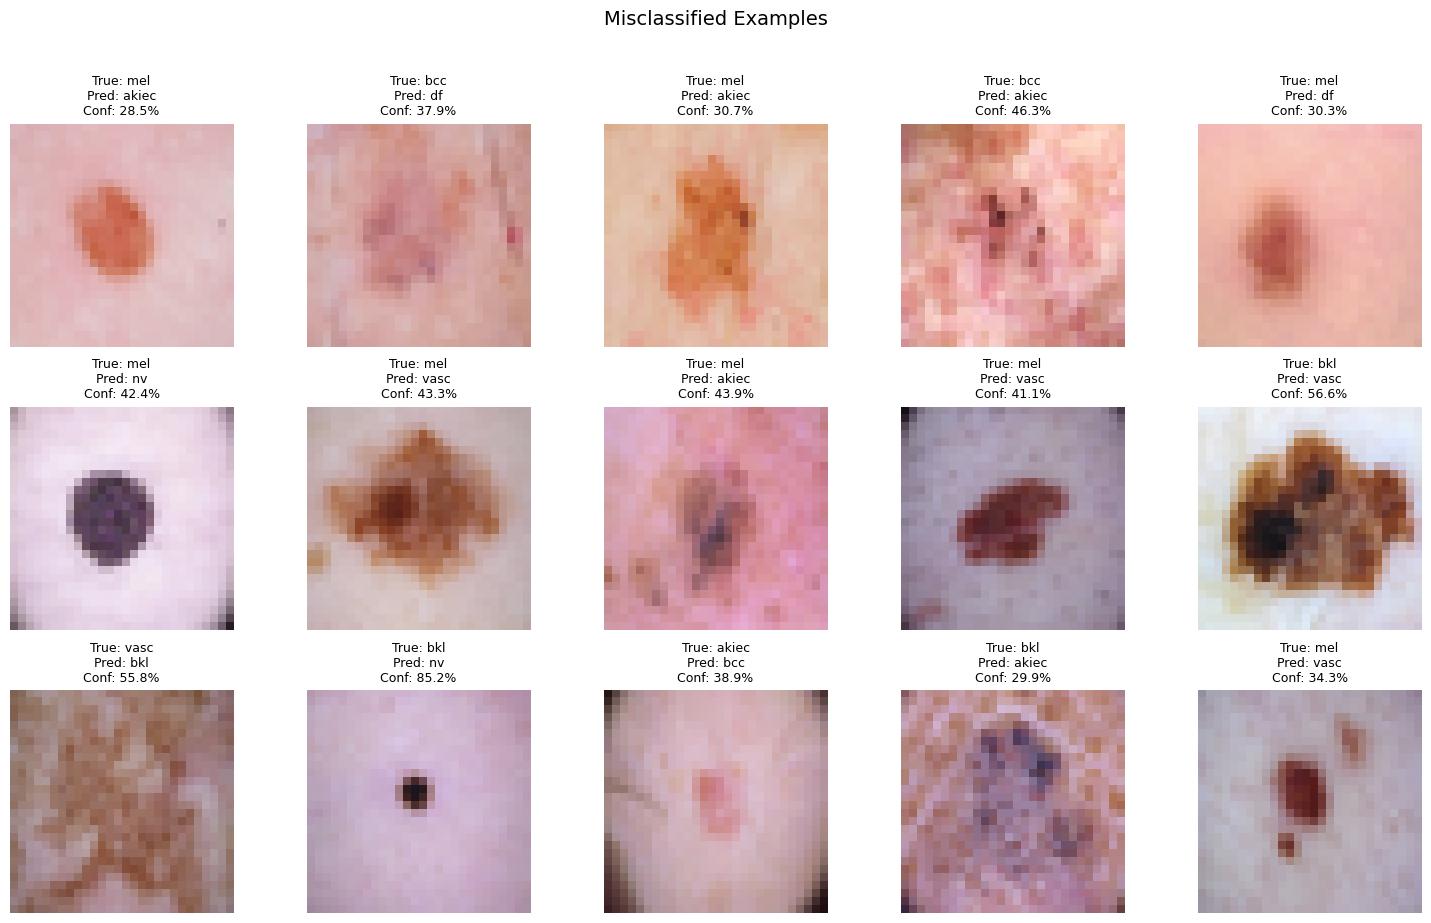

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i, idx in enumerate(misclassified_idx[:15]):
    img = X_test[idx]
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    confidence = y_pred_proba[idx].max() * 100

    axes[i].imshow(img)
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
                     fontsize=9)
    axes[i].axis('off')

plt.suptitle('Misclassified Examples', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('misclassified_examples.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import cv2

# Page configuration
st.set_page_config(
    page_title="Skin Cancer Classifier",
    page_icon="🔬",
    layout="wide"
)

# Load model
@st.cache_resource
def load_model():
    return tf.keras.models.load_model('best_model.keras')

model = load_model()

# Class information
CLASS_NAMES = {
    0: ('akiec', 'Actinic Keratoses', 'Pre-malignant', '⚠️'),
    1: ('bcc', 'Basal Cell Carcinoma', 'Malignant', '🔴'),
    2: ('bkl', 'Benign Keratosis', 'Benign', '🟢'),
    3: ('df', 'Dermatofibroma', 'Benign', '🟢'),
    4: ('mel', 'Melanoma', 'Malignant', '🔴'),
    5: ('nv', 'Melanocytic Nevi', 'Benign', '🟢'),
    6: ('vasc', 'Vascular Lesions', 'Benign', '🟢')
}

# Header
st.title("🔬 Skin Cancer Classification System")
st.markdown("### AI-Powered Dermatoscopic Image Analysis")
st.markdown("---")

# Sidebar
st.sidebar.header("About")
st.sidebar.info("""
This application uses a Convolutional Neural Network (CNN)
trained on the HAM10000 dataset to classify skin lesions
into 7 categories.

**⚠️ Disclaimer:** This tool is for educational purposes only
and should not replace professional medical diagnosis.
""")

# Main content
col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("📤 Upload Image")
    uploaded_file = st.file_uploader(
        "Choose a dermatoscopic image...",
        type=['jpg', 'jpeg', 'png']
    )

    if uploaded_file is not None:
        image = Image.open(uploaded_file).convert('RGB')
        st.image(image, caption='Uploaded Image', use_column_width=True)

with col2:
    st.subheader("🔍 Analysis Results")

    if uploaded_file is not None:
        # Preprocess image
        img_array = np.array(image.resize((28, 28))) / 255.0
        img_array = np.expand_dims(img_array, 0)

        # Predict
        with st.spinner('Analyzing...'):
            predictions = model.predict(img_array, verbose=0)[0]

        # Get top prediction
        pred_class = np.argmax(predictions)
        confidence = predictions[pred_class] * 100

        abbr, full_name, nature, emoji = CLASS_NAMES[pred_class]

        # Display results
        st.markdown(f"### {emoji} **{full_name}**")
        st.markdown(f"**Abbreviation:** {abbr}")
        st.markdown(f"**Nature:** {nature}")
        st.markdown(f"**Confidence:** {confidence:.1f}%")

        # Warning for malignant
        if nature == 'Malignant':
            st.error("⚠️ This lesion is classified as potentially malignant. Please consult a dermatologist immediately.")
        elif nature == 'Pre-malignant':
            st.warning("⚠️ This lesion shows pre-malignant characteristics. Medical consultation is recommended.")
        else:
            st.success("✅ This lesion appears to be benign. Regular monitoring is still advised.")

        # Show all probabilities
        st.markdown("---")
        st.subheader("📊 Probability Distribution")

        for i, prob in enumerate(predictions):
            abbr, full_name, nature, emoji = CLASS_NAMES[i]
            color = "red" if nature == "Malignant" else "orange" if nature == "Pre-malignant" else "green"
            st.markdown(f"**{emoji} {abbr}** ({full_name})")
            st.progress(float(prob))
            st.caption(f"{prob*100:.2f}%")

# Information section
st.markdown("---")
st.subheader("ℹ️ About the Classes")

cols = st.columns(4)
for i, (class_id, info) in enumerate(CLASS_NAMES.items()):
    with cols[i % 4]:
        abbr, full_name, nature, emoji = info
        st.markdown(f"""
        **{emoji} {abbr}**
        {full_name}
        *{nature}*
        """)

# Footer
st.markdown("---")
st.markdown("""
<div style='text-align: center'>
    <p>Built with ❤️ using Streamlit | Model trained on HAM10000 Dataset</p>
</div>
""", unsafe_allow_html=True)


ModuleNotFoundError: No module named 'streamlit'

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 58.8 MB/s eta 0:00:00


In [ ]:
streamlit==1.28.0
tensorflow==2.13.0
numpy==1.24.0
Pillow==10.0.0
opencv-python-headless==4.8.0


In [ ]:
import os

# Create a dummy app.py file if it doesn't exist to prevent errors
# In a real scenario, the content would be populated from the previous Streamlit code block
app_code = '''
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import cv2

st.set_page_config(
    page_title="Skin Cancer Classifier",
    page_icon="🔬",
    layout="wide"
)

@st.cache_resource
def load_model():
    return tf.keras.models.load_model('best_model.keras')

model = load_model()

CLASS_NAMES = {
    0: ('akiec', 'Actinic Keratoses', 'Pre-malignant', '⚠️'),
    1: ('bcc', 'Basal Cell Carcinoma', 'Malignant', '🔴'),
    2: ('bkl', 'Benign Keratosis', 'Benign', '🟢'),
    3: ('df', 'Dermatofibroma', 'Benign', '🟢'),
    4: ('mel', 'Melanoma', 'Malignant', '🔴'),
    5: ('nv', 'Melanocytic Nevi', 'Benign', '🟢'),
    6: ('vasc', 'Vascular Lesions', 'Benign', '🟢')
}

st.title("🔬 Skin Cancer Classification System")
st.markdown("### AI-Powered Dermatoscopic Image Analysis")
st.markdown("---")

col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("📤 Upload Image")
    uploaded_file = st.file_uploader(
        "Choose a dermatoscopic image...",
        type=['jpg', 'jpeg', 'png']
    )

    if uploaded_file is not None:
        image = Image.open(uploaded_file).convert('RGB')
        st.image(image, caption='Uploaded Image', use_column_width=True)

with col2:
    st.subheader("🔍 Analysis Results")

    if uploaded_file is not None:
        img_array = np.array(image.resize((28, 28))) / 255.0
        img_array = np.expand_dims(img_array, 0)

        with st.spinner('Analyzing...'):
            predictions = model.predict(img_array, verbose=0)[0]

        pred_class = np.argmax(predictions)
        confidence = predictions[pred_class] * 100

        abbr, full_name, nature, emoji = CLASS_NAMES[pred_class]

        st.markdown(f"### {emoji} **{full_name}**")
        st.markdown(f"**Abbreviation:** {abbr}")
        st.markdown(f"**Nature:** {nature}")
        st.markdown(f"**Confidence:** {confidence:.1f}%")

        if nature == 'Malignant':
            st.error("⚠️ This lesion is classified as potentially malignant. Please consult a dermatologist immediately.")
        elif nature == 'Pre-malignant':
            st.warning("⚠️ This lesion shows pre-malignant characteristics. Medical consultation is recommended.")
        else:
            st.success("✅ This lesion appears to be benign. Regular monitoring is still advised.")

        st.markdown("---")
        st.subheader("📊 Probability Distribution")

        for i, prob in enumerate(predictions):
            abbr, full_name, nature, emoji = CLASS_NAMES[i]
            color = "red" if nature == "Malignant" else "orange" if nature == "Pre-malignant" else "green"
            st.markdown(f"**{emoji} {abbr}** ({full_name})")
            st.progress(float(prob))
            st.caption(f"{prob*100:.2f}%")

st.markdown("---")
st.subheader("ℹ️ About the Classes")

cols = st.columns(4)
for i, (class_id, info) in enumerate(CLASS_NAMES.items()):
    with cols[i % 4]:
        abbr, full_name, nature, emoji = info
        st.markdown(f"""
        **{emoji} {abbr}**
        {full_name}
        *{nature}*
        """

st.markdown("---")
st.markdown("""
<div style='text-align: center'>
    <p>Built with ❤️ using Streamlit | Model trained on HAM10000 Dataset</p>
</div>
""", unsafe_allow_html=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py created.")

!streamlit run app.py

app.py created.



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.117.223.56:8501



In [ ]:
streamlit run app.py
